# 01 — EDA and Dataset Understanding

This notebook loads the original Consumer Complaint dataset, checks missing values, understands target distribution, analyzes complaint text, and saves a clean NLP base file for the next notebook.

In [1]:
# 01_EDA_AND_DATA_UNDERSTANDING.ipynb
# Customer Complaint Classification System

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------
BASE_DIR = r"C:\Users\v-amaniyar\Downloads\Adhyayan_presentations\NLP_PROJECT"

DATA_DIR = os.path.join(BASE_DIR, "data")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
MODEL_DIR = os.path.join(BASE_DIR, "models")
REPORT_DIR = os.path.join(BASE_DIR, "reports")

for folder in [DATA_DIR, OUTPUT_DIR, MODEL_DIR, REPORT_DIR]:
    os.makedirs(folder, exist_ok=True)

# Put your original file inside data folder
RAW_FILE = os.path.join(DATA_DIR, "complaints_copy.xlsx")

print("Base directory:", BASE_DIR)
print("Raw file path:", RAW_FILE)


Base directory: C:\Users\v-amaniyar\Downloads\Adhyayan_presentations\NLP_PROJECT
Raw file path: C:\Users\v-amaniyar\Downloads\Adhyayan_presentations\NLP_PROJECT\data\complaints_copy.xlsx


In [2]:
# Load dataset

df = pd.read_excel(RAW_FILE)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()


Dataset loaded successfully.
Shape: (78313, 22)


,_index,_type,_id,_score,_source.tags,_source.zip_code,_source.complaint_id,_source.issue,_source.date_received,_source.state,_source.consumer_disputed,_source.product,_source.company_response,_source.company,_source.submitted_via,_source.date_sent_to_company,_source.company_public_response,_source.sub_product,_source.timely,_source.complaint_what_happened,_source.sub_issue,_source.consumer_consent_provided
0,complaint-public-v2,complaint,3211475,0,NaN,90301,3211475,Attempts to collect debt not owed,2019-04-13T12:00:00-05:00,CA,NaN,Debt collection,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-13T12:00:00-05:00,NaN,Credit card debt,Yes,NaN,Debt is not yours,Consent not provided
1,complaint-public-v2,complaint,3229299,0,Servicemember,319XX,3229299,Written notification about debt,2019-05-01T12:00:00-05:00,GA,NaN,Debt collection,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-01T12:00:00-05:00,NaN,Credit card debt,Yes,Good morning my name is XXXX XXXX and I appreciate it if you could help me put a stop to Chase Bank cardmember services. \nIn 2018 I wrote to Chase asking for debt verification and what they sent ...,Didn't receive enough information to verify debt,Consent provided
2,complaint-public-v2,complaint,3199379,0,NaN,77069,3199379,"Other features, terms, or problems",2019-04-02T12:00:00-05:00,TX,NaN,Credit card or prepaid card,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-02T12:00:00-05:00,NaN,General-purpose credit card or charge card,Yes,I upgraded my XXXX XXXX card in XX/XX/2018 and was told by the agent who did the upgrade my anniversary date would not change. It turned the agent was giving me the wrong information in order to u...,Problem with rewards from credit card,Consent provided
3,complaint-public-v2,complaint,2673060,0,NaN,48066,2673060,Trouble during payment process,2017-09-13T12:00:00-05:00,MI,NaN,Mortgage,Closed with explanation,JPMORGAN CHASE & CO.,Web,2017-09-14T12:00:00-05:00,NaN,Conventional home mortgage,Yes,NaN,NaN,Consent not provided
4,complaint-public-v2,complaint,3203545,0,NaN,10473,3203545,Fees or interest,2019-04-05T12:00:00-05:00,NY,NaN,Credit card or prepaid card,Closed with explanation,JPMORGAN CHASE & CO.,Referral,2019-04-05T12:00:00-05:00,NaN,General-purpose credit card or charge card,Yes,NaN,Charged too much interest,NaN


In [3]:
# Basic information

print("Columns:")
print(df.columns.tolist())

print("\nDataset info:")
df.info()


Columns:
['_index', '_type', '_id', '_score', '_source.tags', '_source.zip_code', '_source.complaint_id', '_source.issue', '_source.date_received', '_source.state', '_source.consumer_disputed', '_source.product', '_source.company_response', '_source.company', '_source.submitted_via', '_source.date_sent_to_company', '_source.company_public_response', '_source.sub_product', '_source.timely', '_source.complaint_what_happened', '_source.sub_issue', '_source.consumer_consent_provided']

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78313 entries, 0 to 78312
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   _index                             78313 non-null  object
 1   _type                              78313 non-null  object
 2   _id                                78313 non-null  int64 
 3   _score                             78313 non-null  int64 
 4   _source

In [4]:
# cleaning feature names

def clean_my_columns(df):
    df.columns = [c.replace('_source.', '').lstrip('_') for c in df.columns]
    return df
    
df = clean_my_columns(df)
df.head()

,index,type,id,score,tags,zip_code,complaint_id,issue,date_received,state,consumer_disputed,product,company_response,company,submitted_via,date_sent_to_company,company_public_response,sub_product,timely,complaint_what_happened,sub_issue,consumer_consent_provided
0,complaint-public-v2,complaint,3211475,0,NaN,90301,3211475,Attempts to collect debt not owed,2019-04-13T12:00:00-05:00,CA,NaN,Debt collection,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-13T12:00:00-05:00,NaN,Credit card debt,Yes,NaN,Debt is not yours,Consent not provided
1,complaint-public-v2,complaint,3229299,0,Servicemember,319XX,3229299,Written notification about debt,2019-05-01T12:00:00-05:00,GA,NaN,Debt collection,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-01T12:00:00-05:00,NaN,Credit card debt,Yes,Good morning my name is XXXX XXXX and I appreciate it if you could help me put a stop to Chase Bank cardmember services. \nIn 2018 I wrote to Chase asking for debt verification and what they sent ...,Didn't receive enough information to verify debt,Consent provided
2,complaint-public-v2,complaint,3199379,0,NaN,77069,3199379,"Other features, terms, or problems",2019-04-02T12:00:00-05:00,TX,NaN,Credit card or prepaid card,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-02T12:00:00-05:00,NaN,General-purpose credit card or charge card,Yes,I upgraded my XXXX XXXX card in XX/XX/2018 and was told by the agent who did the upgrade my anniversary date would not change. It turned the agent was giving me the wrong information in order to u...,Problem with rewards from credit card,Consent provided
3,complaint-public-v2,complaint,2673060,0,NaN,48066,2673060,Trouble during payment process,2017-09-13T12:00:00-05:00,MI,NaN,Mortgage,Closed with explanation,JPMORGAN CHASE & CO.,Web,2017-09-14T12:00:00-05:00,NaN,Conventional home mortgage,Yes,NaN,NaN,Consent not provided
4,complaint-public-v2,complaint,3203545,0,NaN,10473,3203545,Fees or interest,2019-04-05T12:00:00-05:00,NY,NaN,Credit card or prepaid card,Closed with explanation,JPMORGAN CHASE & CO.,Referral,2019-04-05T12:00:00-05:00,NaN,General-purpose credit card or charge card,Yes,NaN,Charged too much interest,NaN


In [5]:
# Missing values report

missing_report = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values("missing_percentage", ascending=False)

missing_report


,missing_count,missing_percentage
company_public_response,78309,99.99
tags,67413,86.08
complaint_what_happened,57241,73.09
sub_issue,46297,59.12
consumer_consent_provided,43855,56.00
consumer_disputed,35683,45.56
sub_product,10571,13.50
zip_code,6757,8.63
state,1991,2.54
type,0,0.00


In [6]:
# Save missing value report
missing_report.to_csv(os.path.join(REPORT_DIR, "missing_values_report.csv"))
print("Missing value report saved.")


Missing value report saved.


In [7]:

# Select columns required for NLP classification
# In our dataset:
# complaint_what_happened = complaint text
# product = target category

required_columns = ["complaint_what_happened", "product"]

for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Required column missing: {col}")

df_nlp = df[required_columns].copy()

df_nlp = df_nlp.rename(columns={
    "complaint_what_happened": "complaint_text",
    "product": "category"
})

print("NLP dataset shape before row cleaning:", df_nlp.shape)
df_nlp.head()


NLP dataset shape before row cleaning: (78313, 2)


,complaint_text,category
0,NaN,Debt collection
1,Good morning my name is XXXX XXXX and I appreciate it if you could help me put a stop to Chase Bank cardmember services. \nIn 2018 I wrote to Chase asking for debt verification and what they sent ...,Debt collection
2,I upgraded my XXXX XXXX card in XX/XX/2018 and was told by the agent who did the upgrade my anniversary date would not change. It turned the agent was giving me the wrong information in order to u...,Credit card or prepaid card
3,NaN,Mortgage
4,NaN,Credit card or prepaid card


In [8]:
# Check missing values in selected NLP columns

df_nlp.isnull().sum()


complaint_text    57241
category              0
dtype: int64

In [9]:
# Remove rows where complaint text or category is missing

df_nlp = df_nlp.dropna(subset=["complaint_text", "category"])

# Remove exact duplicate complaints
df_nlp = df_nlp.drop_duplicates(subset=["complaint_text", "category"])

# Reset index
df_nlp = df_nlp.reset_index(drop=True)

print("NLP dataset shape after row cleaning:", df_nlp.shape)
df_nlp.head()


NLP dataset shape after row cleaning: (20937, 2)


,complaint_text,category
0,Good morning my name is XXXX XXXX and I appreciate it if you could help me put a stop to Chase Bank cardmember services. \nIn 2018 I wrote to Chase asking for debt verification and what they sent ...,Debt collection
1,I upgraded my XXXX XXXX card in XX/XX/2018 and was told by the agent who did the upgrade my anniversary date would not change. It turned the agent was giving me the wrong information in order to u...,Credit card or prepaid card
2,"Chase Card was reported on XX/XX/2019. However, fraudulent application have been submitted my identity without my consent to fraudulently obtain services. Do not extend credit without verifying th...","Credit reporting, credit repair services, or other personal consumer reports"
3,"On XX/XX/2018, while trying to book a XXXX XXXX ticket, I came across an offer for {$300.00} to be applied towards the ticket if I applied for a rewards card. I put in my information for the off...","Credit reporting, credit repair services, or other personal consumer reports"
4,my grand son give me check for {$1600.00} i deposit it into my chase account after fund clear my chase bank closed my account never paid me my money they said they need to speek with my grand son ...,Checking or savings account


In [10]:
# Target category distribution

category_counts = df_nlp["category"].value_counts()

print("Number of categories:", df_nlp["category"].nunique())
category_counts


Number of categories: 17


category
Credit card or prepaid card                                                     5027
Checking or savings account                                                     4287
Mortgage                                                                        3246
Credit card                                                                     2068
Credit reporting, credit repair services, or other personal consumer reports    1999
Bank account or service                                                         1649
Debt collection                                                                  930
Money transfer, virtual currency, or money service                               797
Vehicle loan or lease                                                            400
Consumer Loan                                                                    239
Student loan                                                                     140
Money transfers                                         

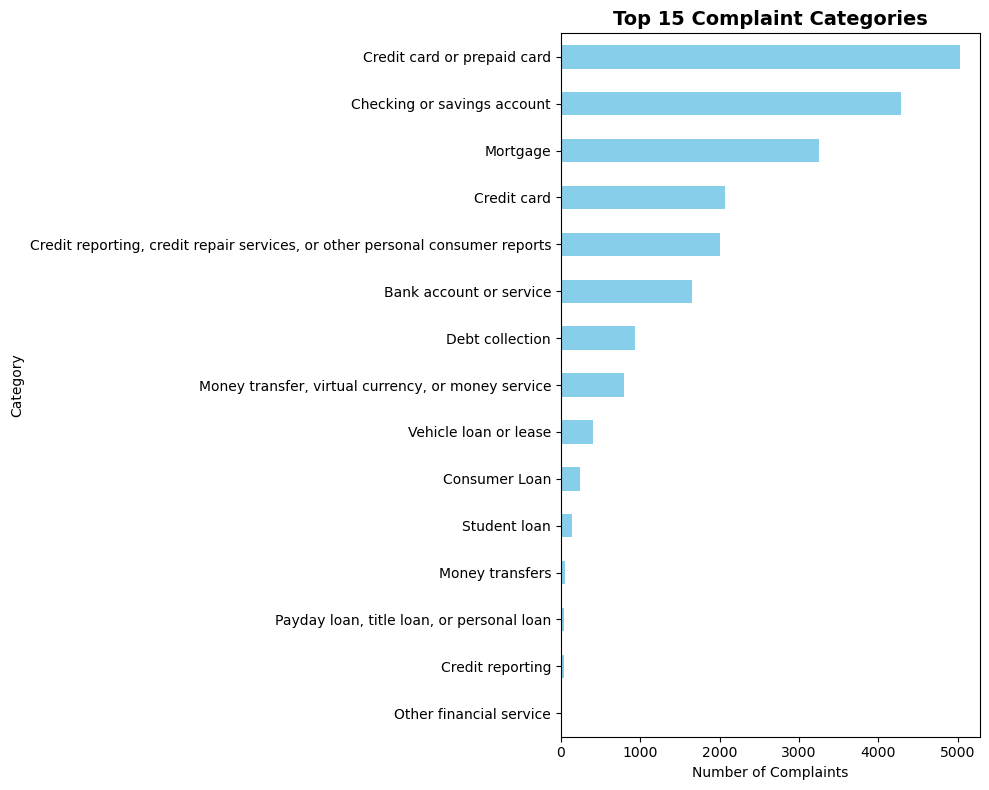

In [11]:
# Plot top complaint categories (Optimized for long labels)

plt.figure(figsize=(10, 8)) 

# Use barh (horizontal) and sort so the highest count is at the top
category_counts.head(15).sort_values(ascending=True).plot(kind="barh", color='skyblue')

plt.title("Top 15 Complaint Categories", fontsize=14, fontweight='bold')
plt.xlabel("Number of Complaints")
plt.ylabel("Category")

# No rotation needed for horizontal charts!
plt.tight_layout()

plt.savefig(os.path.join(REPORT_DIR, "top_15_categories.png"), dpi=300)
plt.show()


In [12]:
# Text length analysis

df_nlp["text_char_length"] = df_nlp["complaint_text"].astype(str).apply(len)
df_nlp["text_word_length"] = df_nlp["complaint_text"].astype(str).apply(lambda x: len(x.split()))

df_nlp[["text_char_length", "text_word_length"]].describe()


,text_char_length,text_word_length
count,20937.000000,20937.000000
mean,1390.028610,253.862540
std,1504.811007,271.283797
min,19.000000,1.000000
25%,532.000000,98.000000
50%,988.000000,182.000000
75%,1745.000000,320.000000
max,31611.000000,5573.000000


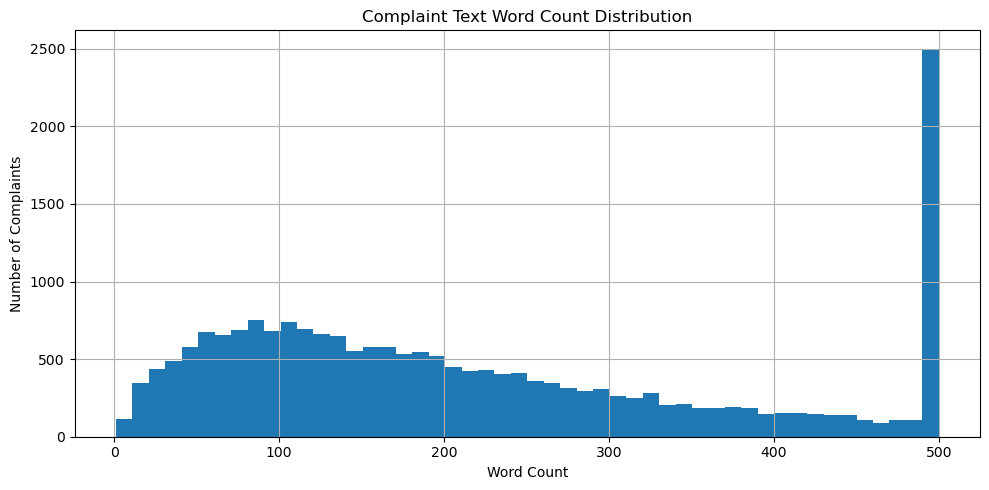

In [13]:
# Plot word length distribution

plt.figure(figsize=(10, 5))
df_nlp["text_word_length"].clip(upper=500).hist(bins=50)
plt.title("Complaint Text Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Number of Complaints")
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "complaint_word_count_distribution.png"), dpi=300)
plt.show()


In [14]:
# Save NLP base dataset
# This file is input for notebook 02.

nlp_base_file = os.path.join(OUTPUT_DIR, "01_nlp_base_complaints.csv")

df_nlp[["complaint_text", "category"]].to_csv(nlp_base_file, index=False, encoding="utf-8")

print("NLP base file saved at:")
print(nlp_base_file)
print("Final shape:", df_nlp[["complaint_text", "category"]].shape)


NLP base file saved at:
C:\Users\v-amaniyar\Downloads\Adhyayan_presentations\NLP_PROJECT\outputs\01_nlp_base_complaints.csv
Final shape: (20937, 2)
